In [1]:
# Celda 1 — Instalar dependencias y montar Drive
!pip install wandb catboost -q
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score
from catboost import CatBoostClassifier
from google.colab import drive
import pickle
import wandb
from google.colab import userdata

wandb.login(key=userdata.get('WANDB_API_KEY'))

warnings.filterwarnings("ignore", category=FutureWarning)

np.random.seed(42)

drive.mount("/content/drive")
DRIVE_PATH = "/content/drive/MyDrive/ProyectoHIGGS/"

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")
print("Setup completado.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.9 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: diego-munozc (diego-munozc-universidad-de-antioquia) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Mounted at /content/drive
Setup completado.


In [2]:
# Celda 2 — Cargar splits desde Drive
X_train = np.load(DRIVE_PATH + "X_train.npy")
X_val   = np.load(DRIVE_PATH + "X_val.npy")
X_test  = np.load(DRIVE_PATH + "X_test.npy")
y_train = np.load(DRIVE_PATH + "y_train.npy")
y_val   = np.load(DRIVE_PATH + "y_val.npy")
y_test  = np.load(DRIVE_PATH + "y_test.npy")

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Separar 10% de train como eval set para early stopping
X_tr, X_ev, y_tr, y_ev = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=42
)
print(f"Train (90%): {X_tr.shape}, Eval (10%): {X_ev.shape}")

Train: (350000, 28), Val: (75000, 28), Test: (75000, 28)
Train (90%): (315000, 28), Eval (10%): (35000, 28)


In [3]:
# Celda 3 — Función de evaluación para CatBoost (5-Fold CV, scaler por fold)
def evaluar_modelo_cv_catboost(model, X_train, y_train, X_val, y_val, X_test, y_test,
                                nombre, k=5):
    """
    Evalúa CatBoost con K-Fold CV. Scaler dentro de cada fold (sin leakage).
    Cada fold separa 10% del train fold como eval_set para early stopping.
    """
    kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    auc_folds, f1_folds, acc_folds, prec_folds, rec_folds = [], [], [], [], []

    for tr_idx, vl_idx in kf.split(X_train, y_train):
        scaler_cv = StandardScaler()
        X_tr_fold = scaler_cv.fit_transform(X_train[tr_idx])
        X_vl_fold = scaler_cv.transform(X_train[vl_idx])

        X_sub_tr, X_sub_ev, y_sub_tr, y_sub_ev = train_test_split(
            X_tr_fold, y_train[tr_idx], test_size=0.1,
            stratify=y_train[tr_idx], random_state=42
        )
        model.fit(X_sub_tr, y_sub_tr, eval_set=(X_sub_ev, y_sub_ev),
                  verbose=False)
        y_prob = model.predict_proba(X_vl_fold)[:, 1]
        y_pred = model.predict(X_vl_fold)
        auc_folds.append(roc_auc_score(y_train[vl_idx], y_prob))
        f1_folds.append(f1_score(y_train[vl_idx], y_pred))
        acc_folds.append(accuracy_score(y_train[vl_idx], y_pred))
        prec_folds.append(precision_score(y_train[vl_idx], y_pred))
        rec_folds.append(recall_score(y_train[vl_idx], y_pred))

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_val_sc   = scaler.transform(X_val)
    X_test_sc  = scaler.transform(X_test)

    X_sub_tr, X_sub_ev, y_sub_tr, y_sub_ev = train_test_split(
        X_train_sc, y_train, test_size=0.1, stratify=y_train, random_state=42
    )
    model.fit(X_sub_tr, y_sub_tr, eval_set=(X_sub_ev, y_sub_ev), verbose=False)

    return {
        "Modelo": nombre,
        "AUC_CV_mean": np.mean(auc_folds),
        "AUC_CV_std":  np.std(auc_folds),
        "F1_CV_mean":  np.mean(f1_folds),
        "F1_CV_std":   np.std(f1_folds),
        "Acc_CV_mean": np.mean(acc_folds),
        "Acc_CV_std":  np.std(acc_folds),
        "Precision_CV_mean": np.mean(prec_folds), "Precision_CV_std": np.std(prec_folds),
        "Recall_CV_mean": np.mean(rec_folds), "Recall_CV_std": np.std(rec_folds),
        "AUC_val": roc_auc_score(y_val,  model.predict_proba(X_val_sc)[:, 1]),
        "F1_val":  f1_score(y_val,  model.predict(X_val_sc)),
        "Acc_val": accuracy_score(y_val, model.predict(X_val_sc)),
        "Precision_val": precision_score(y_val, model.predict(X_val_sc)),
        "Recall_val": recall_score(y_val, model.predict(X_val_sc)),
        "AUC_test": roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1]),
        "F1_test":  f1_score(y_test,  model.predict(X_test_sc)),
        "Acc_test": accuracy_score(y_test, model.predict(X_test_sc)),
        "Precision_test": precision_score(y_test, model.predict(X_test_sc)),
        "Recall_test": recall_score(y_test, model.predict(X_test_sc)),
        "_scaler": scaler,
        "_model": model,
    }


def tabla_resultados(resultados_lista):
    """Formatea lista de resultados como DataFrame con IC."""
    rows = []
    for r in resultados_lista:
        rows.append({
            "Modelo": r["Modelo"],
            "AUC CV (mean±2σ)": f"{r['AUC_CV_mean']:.3f} ± {2*r['AUC_CV_std']:.3f}",
            "AUC Val":  f"{r['AUC_val']:.3f}",
            "AUC Test": f"{r['AUC_test']:.3f}",
            "F1 Test":  f"{r['F1_test']:.3f}",
            "Acc Test": f"{r['Acc_test']:.3f}",
            "Precision Test": f"{r['Precision_test']:.3f}",
            "Recall Test": f"{r['Recall_test']:.3f}",
        })
    return pd.DataFrame(rows).set_index("Modelo")

Entrenando CatBoost...
  lr=0.05, depth=5  , l2=1: AUC val = 0.8097  (stop @ iter 499)
  lr=0.05, depth=5  , l2=3: AUC val = 0.8094  (stop @ iter 499)
  lr=0.05, depth=5  , l2=10: AUC val = 0.8095  (stop @ iter 499)
  lr=0.05, depth=8  , l2=1: AUC val = 0.8216  (stop @ iter 499)
  lr=0.05, depth=8  , l2=3: AUC val = 0.8215  (stop @ iter 499)
  lr=0.05, depth=8  , l2=10: AUC val = 0.8216  (stop @ iter 499)
  lr=0.05, depth=12 , l2=1: AUC val = 0.8270  (stop @ iter 499)
  lr=0.05, depth=12 , l2=3: AUC val = 0.8273  (stop @ iter 497)
  lr=0.05, depth=12 , l2=10: AUC val = 0.8273  (stop @ iter 499)
  lr=0.10, depth=5  , l2=1: AUC val = 0.8179  (stop @ iter 497)
  lr=0.10, depth=5  , l2=3: AUC val = 0.8175  (stop @ iter 498)
  lr=0.10, depth=5  , l2=10: AUC val = 0.8179  (stop @ iter 499)
  lr=0.10, depth=8  , l2=1: AUC val = 0.8265  (stop @ iter 497)
  lr=0.10, depth=8  , l2=3: AUC val = 0.8268  (stop @ iter 499)
  lr=0.10, depth=8  , l2=10: AUC val = 0.8272  (stop @ iter 499)
  lr=0.10, d

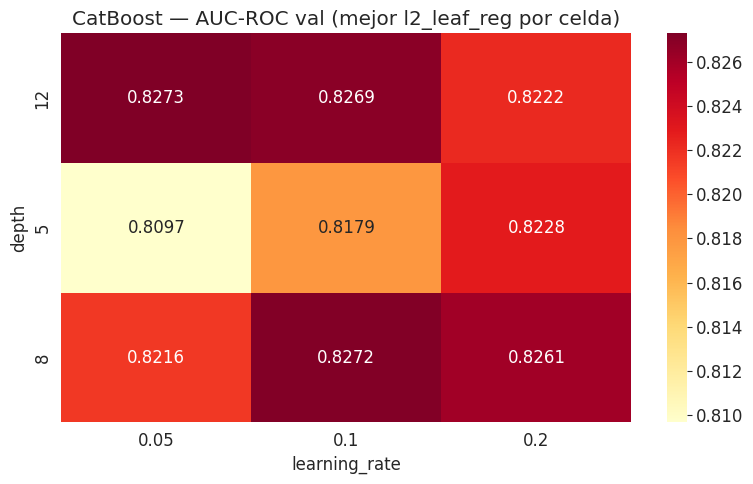


Top 5 configuraciones:
 learning_rate depth  l2_leaf_reg      AUC  n_iter
          0.05    12            3 0.827305     497
          0.05    12           10 0.827301     499
          0.10     8           10 0.827215     499
          0.05    12            1 0.827047     499
          0.10    12           10 0.826911     287

Mejores parámetros CatBoost: {'learning_rate': 0.05, 'depth': 12, 'l2_leaf_reg': 3}


AUC_CV_2std,▁
AUC_CV_mean,▁
AUC_test,▁
AUC_val,▁▁▁▆▆▆███▄▄▄███▆▇█▆▆▆▇█▇▃▅▆█
Acc_test,▁
F1_test,▁
l2_leaf_reg,▁▃█▁▃█▁▃█▁▃█▁▃█▁▃█▁▃█▁▃█▁▃█
lr,▁▁▁▁▁▁▁▁▁▃▃▃▃▃▃▃▃▃█████████
n_iter,███████████████▄▅▄███▅▇▄▁▂▂
AUC_CV_2std,0.00294
AUC_CV_mean,0.82272


In [4]:
# Celda 4 — CatBoost (gradient boosting con árboles simétricos)
# NOTA: CatBoost usa árboles simétricos (depth, no leaves).
# Ordened boosting reduce overfitting sin necesidad de subsample agresivo.
# Prokhorenkova et al. (2018): CatBoost ~0.870-0.880 AUC en HIGGS.

nombre_modelo = "CatBoost"

wandb.init(project="higgs-boson", name="CatBoost", config={
    "learning_rate_grid": [0.05, 0.1, 0.2],
    "depth_grid": [5, 8, 12],
    "l2_leaf_reg_grid": [1, 3, 10],
    "iterations": 500,
    "early_stopping_rounds": 20,
})
print(f"Entrenando {nombre_modelo}...")

param_grid_cb = {
    "learning_rate": [0.05, 0.1, 0.2],
    "depth":         [5, 8, 12],
    "l2_leaf_reg":   [1, 3, 10],
}
best_auc_cb = 0
best_params_cb = {}
cb_results_grid = []

for lr in param_grid_cb["learning_rate"]:
    for depth in param_grid_cb["depth"]:
        for l2 in param_grid_cb["l2_leaf_reg"]:
            cb = CatBoostClassifier(
                iterations=500, learning_rate=lr, depth=depth,
                l2_leaf_reg=l2, early_stopping_rounds=20,
                eval_metric="AUC", random_seed=42,
                thread_count=-1, verbose=False
            )
            cb.fit(X_tr, y_tr, eval_set=(X_ev, y_ev), verbose=False)
            auc = roc_auc_score(y_val, cb.predict_proba(X_val)[:, 1])
            n_iter = cb.get_best_iteration()
            cb_results_grid.append({
                "learning_rate": lr, "depth": str(depth),
                "l2_leaf_reg": l2, "AUC": auc, "n_iter": n_iter
            })
            wandb.log({"lr": lr, "depth": str(depth), "l2_leaf_reg": l2,
                        "AUC_val": auc, "n_iter": n_iter})
            print(f"  lr={lr:.2f}, depth={str(depth):3s}, l2={l2}: AUC val = {auc:.4f}  (stop @ iter {n_iter})")
            if auc > best_auc_cb:
                best_auc_cb = auc
                best_params_cb = {"learning_rate": lr, "depth": depth,
                                  "l2_leaf_reg": l2}

df_cb_grid = pd.DataFrame(cb_results_grid)

# Heatmap: learning_rate × depth promediado sobre l2_leaf_reg
pivot_cb = df_cb_grid.pivot_table(index="depth", columns="learning_rate",
                                    values="AUC", aggfunc="max")
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_cb, annot=True, fmt=".4f", cmap="YlOrRd")
plt.title("CatBoost — AUC-ROC val (mejor l2_leaf_reg por celda)")
plt.xlabel("learning_rate")
plt.ylabel("depth")
plt.tight_layout()
plt.savefig(DRIVE_PATH + "fig_catboost_hiperparametro.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 configuraciones:")
print(df_cb_grid.sort_values("AUC", ascending=False).head(5)
      [["learning_rate", "depth", "l2_leaf_reg", "AUC", "n_iter"]].to_string(index=False))

print(f"\nMejores parámetros CatBoost: {best_params_cb}")
cb_best = CatBoostClassifier(
    iterations=500, **best_params_cb,
    early_stopping_rounds=20, eval_metric="AUC",
    random_seed=42, thread_count=-1, verbose=False
)
result = evaluar_modelo_cv_catboost(cb_best, X_train, y_train, X_val, y_val,
                                     X_test, y_test, nombre_modelo)

wandb.log({
    "AUC_CV_mean": result["AUC_CV_mean"],
    "AUC_CV_2std": 2 * result["AUC_CV_std"],
    "AUC_val": result["AUC_val"],
    "AUC_test": result["AUC_test"],
    "F1_test": result["F1_test"],
    "Acc_test": result["Acc_test"],
})
wandb.finish()

In [5]:
# Celda 5 — Guardar resultado y modelo
df_result = tabla_resultados([result])
print(df_result.to_string())

safe_name = nombre_modelo.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "").replace("=", "").replace(",", "")
df_result.to_csv(DRIVE_PATH + f"resultado_{safe_name}.csv")

with open(DRIVE_PATH + f"modelo_{safe_name}.pkl", "wb") as f:
    pickle.dump({"model": result["_model"], "scaler": result["_scaler"]}, f)

print(f"\nArtefactos guardados: resultado_{safe_name}.csv + modelo_{safe_name}.pkl")

         AUC CV (mean±2σ) AUC Val AUC Test F1 Test Acc Test Precision Test Recall Test
Modelo                                                                                
CatBoost    0.823 ± 0.003   0.827    0.825   0.761    0.744          0.752       0.771

Artefactos guardados: resultado_CatBoost.csv + modelo_CatBoost.pkl
